In [30]:
using PhDProject
using JLD2
using ITensors
using Plots
using ProgressMeter
using LinearAlgebra
using SparseArrays
using Kronecker

Correlation matrix propagator


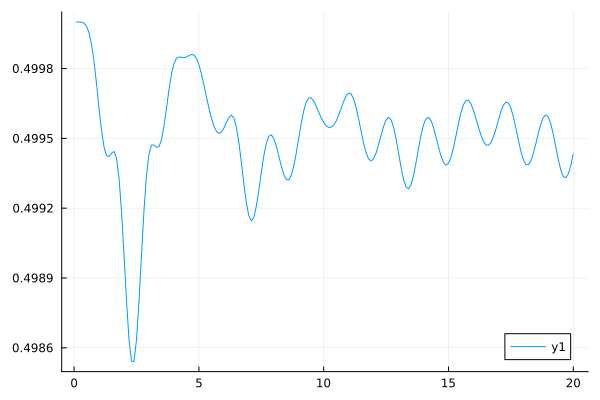

Calculating Λ(t) from the single particle correlation matrix.


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


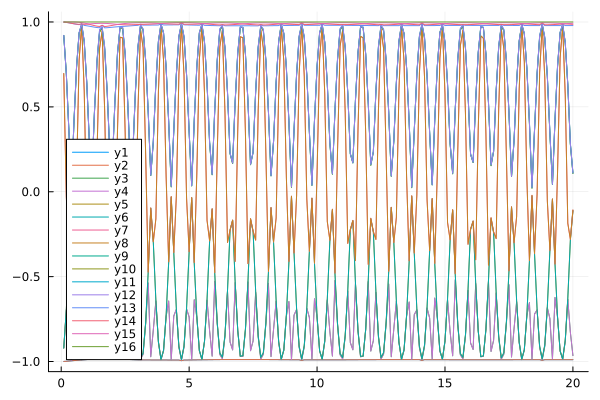

In [33]:
function propagate_correlations(Ci,H_single,times)
    """
    The correlation matrix C_ij = expect(cdag[j]*c[i]) propagates according to
    C_ij(t) =U*C_ij(0)*U', but G_ij = expect(cdag[i]*c[j]) doesn't.This is why 
    the correlation matrices are transposed before calculating the reduced density
    matrix as the formula uses the second definition.
    """
    δt = times[2] - times[1]
    
   
    U_step = exp(-im*δt*H_single)

    corrs = Vector{Any}(undef,length(times))
    corrs[1] = U_step*Ci*U_step'
    for i in 2:length(times)
        corrs[i] = U_step*corrs[i-1]*U_step'
    end
    return corrs
end
function ρ_to_Λ(ρ,Ns)
    d = 2^Ns
    Λ = zeros(ComplexF64, d^2, d^2) 
    for i_s=1:d, j_s=1:d
        for i_a=1:d, j_a=1:d  
            Λ[(i_s-1)*d + j_s, (i_a-1)*d + j_a] = 
                conj(d*ρ[(i_s-1)*d + i_a, (j_s-1)*d + j_a])
        end
    end
    return Λ
end
function spin_operators(M)

    # Build sparse matrix version of basic spin (Pauli) operators :
    sp = spdiagm(2,2,1=>ones(1))
    sm = spdiagm(2,2,-1=>ones(1))
    sz = spdiagm(2,2,0=>[1;-1]);
    num = spdiagm(2,2,0=>[0;1])
    # Notice there are NO factors of (1/2) for spin-1/2 included here.

    # Construct spin operators for each spin in the full Hilbert space :
    Sz = Vector{Any}(undef, M)
    Sp = Vector{Any}(undef, M)
    Sm = Vector{Any}(undef, M)
    Num = Vector{Any}(undef,M)
    for m=1:M
        Sz[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sz),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Sp[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sp),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Sm[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sm),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Num[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),num),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
    end
    return Sz,Sp,Sm,Num
end
function JW_string_mat(Sz,site,M)
    Z = 1.0*Matrix(I, 2^M, 2^M)
    for q=1:(site-1)
        Z = Z*Sz[q];
    end
    return Z
end
function matrix_operators(M)

    Sz,Sp,Sm,_ = spin_operators(M)
    cdag_mat = Vector{Any}(undef,M)
    c_mat = Vector{Any}(undef,M)

    for n=1:M
        #Build JW_string
        Z = JW_string_mat(Sz,n,M)
        cdag_mat[n] = Z*Sm[n]
        c_mat[n]  = Z*Sp[n]
    end
    return cdag_mat,c_mat
   
end
function calculate_ρ_using_G(corr,N_ring,qS,qA)
    """
    G is a the single particle correlation matrix covering the system and ancilla modes. 
    ρ = det(1-G)*e^A,
    A = ∑_ij [log(G(1-G)^-1)]_ij cdag[i]c[j].
    log(G(1-G)^(-1))_ij = α_ij


    """

    G = transpose(corr[1:2*N_ring,1:2*N_ring])

    ###Implements equation connecting the reduced density matrix to the single particle correlation matrix.
    Id = Diagonal(ones(Float64,2*N_ring))    
    α = matrix_log(G*pinv(Id-G))

    A = complex(zeros(2^(2*N_ring),2^(2*N_ring)))
    cdag_mat,c_mat = matrix_operators(2*N_ring)
    _,Sp,Sm,_ = spin_operators(2*N_ring)
    for (i, creator_i) in enumerate(cdag_mat)
        for (j, annihilator_j) in enumerate(c_mat)
            corr_op = Matrix(creator_i)*Matrix(annihilator_j)
            A += α[i, j] * corr_op
        end
    end

    ρ = det(Id-G)*exp(A)

    ##PH transform
    for index in qA
        gate = Sp[index] + Sm[index]
        ρ = gate*ρ*gate'
    end


    ##checks it's a valid density matrix up to a tolerance 1e-5
    ρ_test(ρ,1e-5) 

    ##reshape to give the map
    Λ = ρ_to_Λ(ρ,N_ring) 
    return Λ
end 
function spectral_function(w,spec_fun_type,thermal_chain_number,Γ,β,μ,D)


    f = 1 ./(exp.(β*(w .- μ)).+ 1)
    if thermal_chain_number == 1
        renorm = 1 .- f
    elseif thermal_chain_number == 2
        renorm = f
    end

    if spec_fun_type == "box"
        ρ = (1/(2*D))*(heaviside(w .+ D) .- heaviside(w .- D)).*renorm
        J =  (Γ*D/π)*ρ
    elseif spec_fun_type =="ellipse"
        ρ = real((2/(π*D))*sqrt.(Complex.(1 .-(w/D).^2)).*renorm)
        J =  (Γ*D/π)*ρ
    end
    replace_nan(J)
    return J
end
function chain_mapping_coeffs(spec_fun_type,thermal_chain_number,N_bath,Γ,β,μ,D;kwargs...)

    N_chain = get(kwargs,:N_chain,N_bath)
    @assert(N_chain <= N_bath)

    couplings,energies = complex(zeros(N_bath)),complex(zeros(N_bath))
    spec_fun(w) = spectral_function(w,spec_fun_type,thermal_chain_number,Γ,β,μ,D)
    supp = (-D,D)
    my_meas = PhDProject.Measure("my_meas", spec_fun, supp, false, Dict())
    my_op = PhDProject.OrthoPoly("my_op", N_chain-1, my_meas; Nquad=100000);
    α_coeffs,β_coeffs = PhDProject.coeffs(my_op)[:,1],PhDProject.coeffs(my_op)[:,2]
        

    if length(α_coeffs)<N_bath
        energies[1:N_chain] = α_coeffs
        couplings[1:N_chain] = sqrt.(β_coeffs)
        energies[N_chain+1:end] .= α_coeffs[N_chain]
        couplings[N_chain+1:end] .= sqrt(β_coeffs[N_chain])
    else
        energies = α_coeffs
        couplings = sqrt.(β_coeffs)
    end
    return energies,couplings
end
function initialise_setup(N_ring,J,B,compute_maps_bool,N_bath,spec_fun_type,Γ,β,μ,D;kwargs...)


    if compute_maps_bool ==true
        qS = 1:N_ring
        qA = N_ring+1:2*N_ring
        q = 1:2*N_ring
        qbath_full = 2*N_ring+1:2:2*(N_ring+N_bath)
        qbath_empty = 2*N_ring+2:2:2*(N_ring+N_bath)
    else
        qS = 1:N_ring
        q = qS
        qbath_full = N_ring+1:2:2*(N_ring+N_bath)
        qbath_empty = N_ring+2:2:2*(N_ring+N_bath)
    end

    #Creating chain coefficients
    energies_full,couplings_full = chain_mapping_coeffs(spec_fun_type,1,N_bath,Γ,β,μ,D;kwargs...)
    energies_empty,couplings_empty = chain_mapping_coeffs(spec_fun_type,2,N_bath,Γ,β,μ,D;kwargs...)

    #Build single particle hamiltonian
    if compute_maps_bool == true
        H_single = complex(zeros(2*N_ring+2*N_bath,2*N_ring+2*N_bath))
    else
        H_single = complex(zeros(N_ring+N_bath,2*N_ring+2*N_bath))
    end


    #Create system hamiltonian terms
    for i =1:N_ring
        H_single[qS[i],qS[i]] = -2*B
        if i <N_ring
            H_single[qS[i+1],qS[i]] = -2*J
            H_single[qS[i],qS[i+1]] = -2*J
        elseif i!= 1
            @assert(i==N_ring)
            H_single[qS[1],qS[i]] = -2*J
            H_single[qS[i],qS[1]] = -2*J
        end
    end

    #create system bath coupling terms
    H_single[qS[end],qbath_full[1]] = couplings_full[1]
    H_single[qbath_full[1],qS[end]] = conj(couplings_full[1])

    H_single[qS[end],qbath_empty[1]] = couplings_empty[1]
    H_single[qbath_empty[1],qS[end]] = conj(couplings_empty[1])

    #create bath terms
    for i=1:N_bath
        H_single[qbath_full[i],qbath_full[i]] = energies_full[i]
        H_single[qbath_empty[i],qbath_empty[i]] = energies_empty[i]
        if i < N_bath
            H_single[qbath_full[i],qbath_full[i+1]] = couplings_full[i+1]
            H_single[qbath_full[i+1],qbath_full[i]] = conj(couplings_full[i+1])

            H_single[qbath_empty[i],qbath_empty[i+1]] = couplings_empty[i+1]
            H_single[qbath_empty[i+1],qbath_empty[i]] = conj(couplings_empty[i+1])
        end
    end

    #create initial correlation matrix
    Ci = complex(zeros(size(H_single)))
    [Ci[i,i] = 1 for i in qbath_full]

    if compute_maps_bool == true
        for i =1:N_ring 
            Ci[qS[i],qS[i]] = 0.5
            Ci[qS[i],qA[i]] = 0.5
            Ci[qA[i],qS[i]] = 0.5
            Ci[qA[i],qA[i]] = 0.5
        end
    end
    return Ci,H_single,q,qA,qS
end



#spin ring parameters
N_ring = 2
J = 1
B = 2   
compute_maps_bool = true

#Chain mapping parameters
N_bath = 25
N_chain = 20
β = 1
μ = 0
Γ = 0.2
D = 1
spec_fun_type = "ellipse"

#evolution parameters
δt = 0.1
T = 20
times = range(δt,stop=T,step=δt)

Ci,H_single,q,qA,qS = initialise_setup(N_ring,J,B,compute_maps_bool,N_bath,spec_fun_type,Γ,β,μ,D;N_chain)
heatmap(real.(H_single))

println("Correlation matrix propagator")
corrs = propagate_correlations(Ci,H_single,times)
den = [corr[1,1] for corr in corrs]
display(Plots.plot(times,real.(den)))


Λ_vec = similar(corrs)
println("Calculating Λ(t) from the single particle correlation matrix.")
@showprogress for i =1:length(corrs)
    Λ_vec[i]  = calculate_ρ_using_G(corrs[i],N_ring,qS,qA)
end

spectra_Λ = complex(zeros(length(Λ_vec),size(Λ_vec[1])[1]))
@showprogress for i =1:length(corrs)
    spectra_Λ[i,:] = eigen(Λ_vec[i]).values   
end

display(Plots.plot(times,real.(spectra_Λ)))